In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kuldeepjangra/e-commerce-customer-churn-dataset-200k-records/ecommerce_customer_churn_large.csv


# Introduction

Customer churn is one of the most critical business challenges in e-commerce.

In this notebook, we build a high-performance churn prediction system using XGBoost, feature engineering, hyperparameter tuning, and model explainability techniques.

# Imports

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import optuna

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

from xgboost import XGBClassifier

# Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/kuldeepjangra/e-commerce-customer-churn-dataset-200k-records/ecommerce_customer_churn_large.csv')

df.head()

,customer_id,age,gender,city,tenure_months,avg_order_value,total_orders,last_purchase_days_ago,support_tickets,subscription_type,churn
0,100000,56,Female,Mumbai,82,7722,56,704,49,Basic,1
1,100001,69,Female,Kolkata,28,2127,248,357,39,Basic,0
2,100002,46,Male,Delhi,98,2775,68,121,23,Platinum,0
3,100003,32,Female,Pune,46,1698,309,39,47,Silver,0
4,100004,60,Female,Bangalore,90,6520,147,403,32,Silver,0


# Data Overview

In [4]:
df.shape

df.info()

df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   customer_id             200000 non-null  int64 
 1   age                     200000 non-null  int64 
 2   gender                  200000 non-null  object
 3   city                    200000 non-null  object
 4   tenure_months           200000 non-null  int64 
 5   avg_order_value         200000 non-null  int64 
 6   total_orders            200000 non-null  int64 
 7   last_purchase_days_ago  200000 non-null  int64 
 8   support_tickets         200000 non-null  int64 
 9   subscription_type       200000 non-null  object
 10  churn                   200000 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 16.8+ MB


,count,mean,std,min,25%,50%,75%,max
customer_id,200000.0,199999.500000,57735.171256,100000.0,149999.75,199999.5,249999.25,299999.0
age,200000.0,43.477170,14.983060,18.0,31.00,43.0,56.00,69.0
tenure_months,200000.0,59.816265,34.331202,1.0,30.00,60.0,90.00,119.0
avg_order_value,200000.0,5103.223420,2827.789332,200.0,2655.00,5094.0,7547.00,9999.0
total_orders,200000.0,249.919035,144.009220,1.0,125.00,250.0,375.00,499.0
last_purchase_days_ago,200000.0,364.573055,210.814554,0.0,182.00,364.0,547.00,729.0
support_tickets,200000.0,24.461705,14.448645,0.0,12.00,24.0,37.00,49.0
churn,200000.0,0.372135,0.483375,0.0,0.00,0.0,1.00,1.0


# Feature Engineering

## Revenue Feature

In [5]:
df['total_revenue'] = (
    df['avg_order_value'] *
    df['total_orders']
)

## Order Frequency

In [6]:
df['order_frequency'] = (
    df['total_orders'] /
    (df['tenure_months'] + 1)
)

## Support Ratio

In [7]:
df['support_ratio'] = (
    df['support_tickets'] /
    (df['total_orders'] + 1)
)

## Customer Value Score

In [8]:
df['value_score'] = (
    df['avg_order_value'] *
    df['tenure_months']
)

# Encoding

In [9]:
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Correlation Heatmap

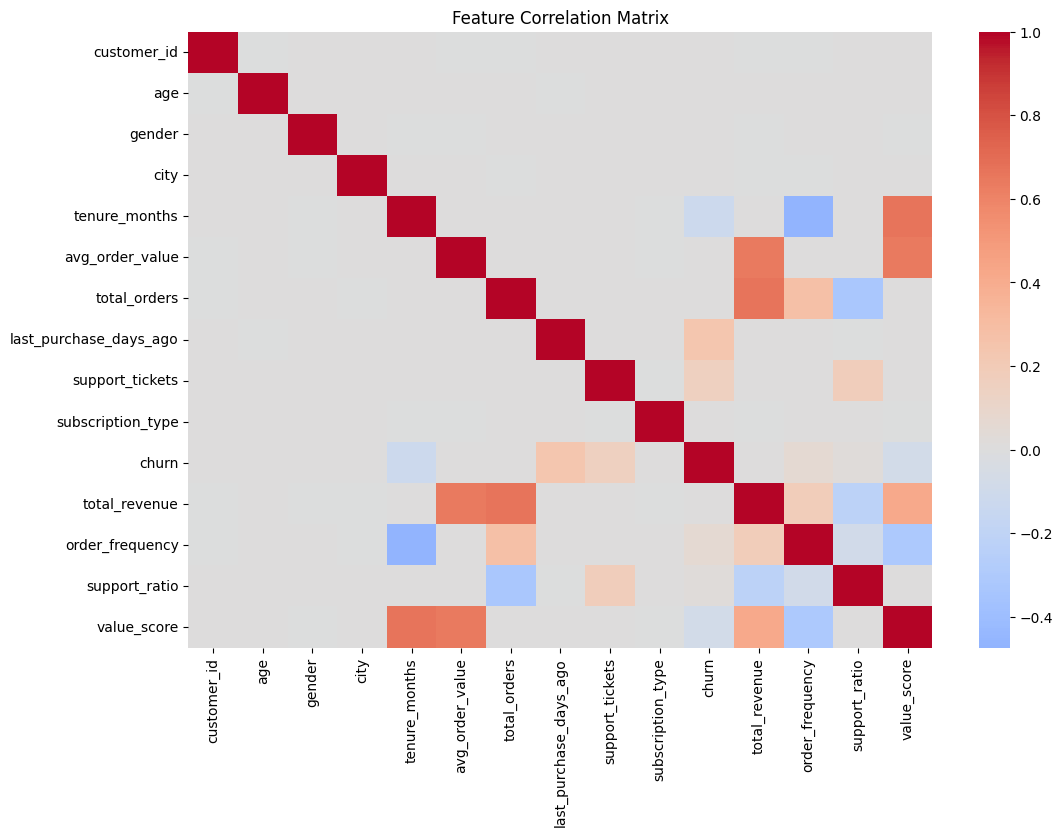

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')
plt.show()

# Train-Test Split

In [11]:
X = df.drop('churn', axis=1)

y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost Model

In [12]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# Predictions

In [13]:
preds = xgb.predict(X_test)

probs = xgb.predict_proba(X_test)[:,1]

# Evaluation

In [14]:
accuracy = accuracy_score(y_test, preds)

precision = precision_score(y_test, preds)

recall = recall_score(y_test, preds)

f1 = f1_score(y_test, preds)

roc = roc_auc_score(y_test, probs)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'ROC AUC  : {roc:.4f}')

Accuracy : 0.6589
Precision: 0.5728
Recall   : 0.3280
F1 Score : 0.4172
ROC AUC  : 0.6769


# Confusion Matrix

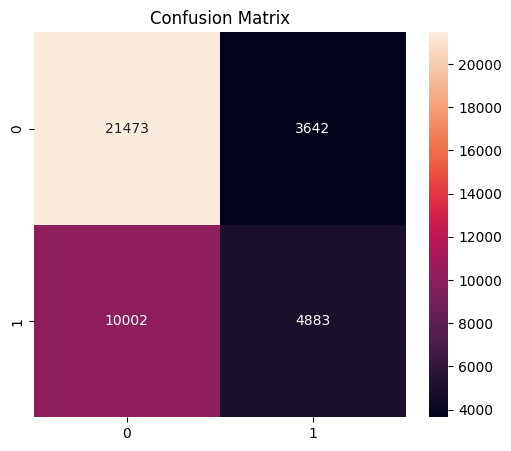

In [15]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

# ROC Curve

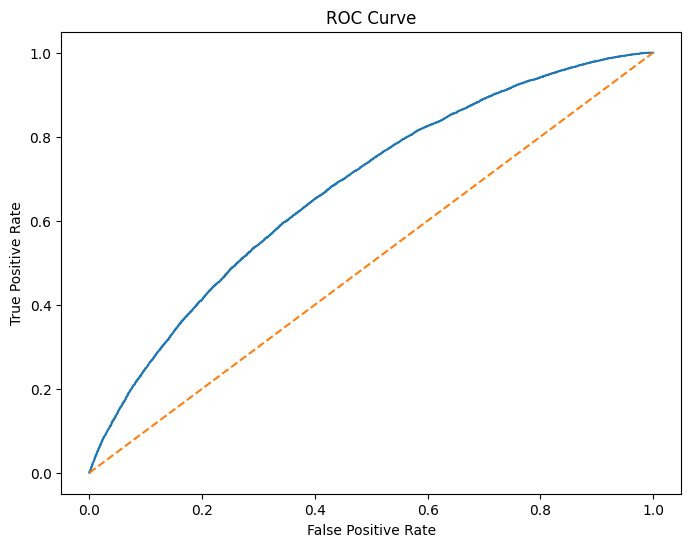

In [16]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

# Feature Importance

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

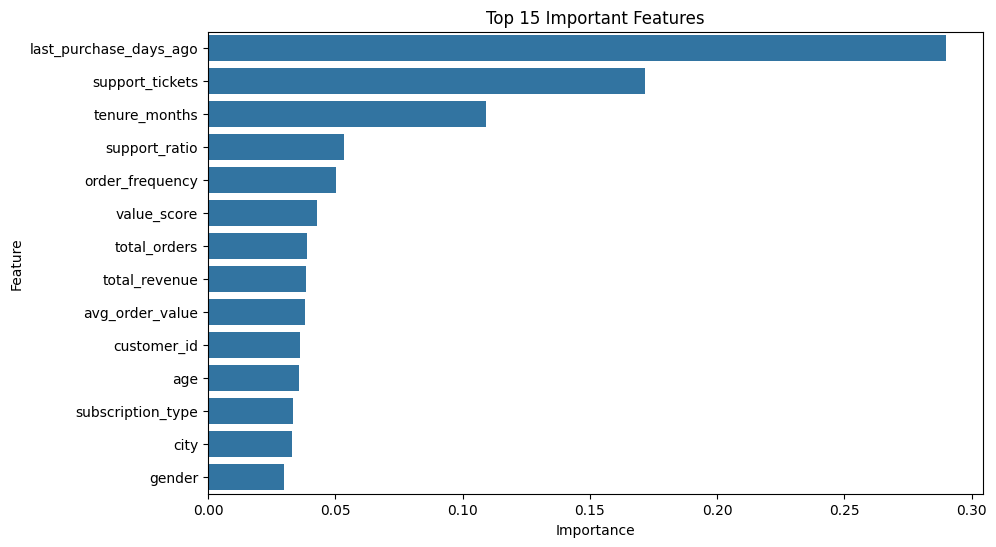

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Important Features')
plt.show()

# SHAP Explainability

In [19]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

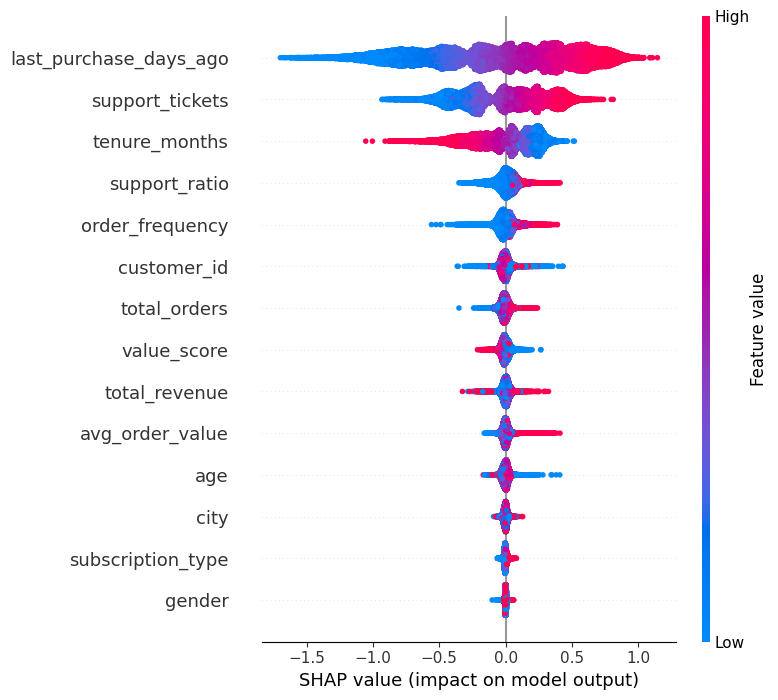

In [20]:
shap.summary_plot(
    shap_values,
    X_test
)

# Hyperparameter Tuning with RandomizedSearchCV

## Why Hyperparameter Tuning?

Hyperparameter tuning helps find the optimal combination of XGBoost parameters, improving predictive performance and reducing overfitting.

## Define Parameter Grid

In [21]:
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10)
}

## Initialize XGBoost

In [22]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

## Run Randomized Search

In [23]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79d0db28faa0>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79d0db291220>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79d0d8b90b60>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79d15525b8c0>},
                   random_state=42, scoring='roc_auc', verbose=2)

## Best Parameters

In [24]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC Score:")
print(random_search.best_score_)

Best Parameters:
{'colsample_bytree': np.float64(0.6488152939379115), 'gamma': np.float64(0.2475884550556351), 'learning_rate': np.float64(0.02031655633456552), 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 661, 'subsample': np.float64(0.8650089137415928)}

Best ROC-AUC Score:
0.6781041829835399


## Train Optimized Model

In [25]:
best_xgb = random_search.best_estimator_

best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6488152939379115), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=np.float64(0.2475884550556351), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.02031655633456552), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=661, n_jobs=None,
              num_parallel_tree=None, ...)

## Evaluate Optimized Model

In [26]:
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.66015
Precision: 0.57559433188898
Recall   : 0.3301981860933826
F1 Score : 0.41965505464480873
ROC-AUC  : 0.6814127689818639


## Compare Before vs After Tuning

In [27]:
baseline_probs = xgb.predict_proba(X_test)[:, 1]

baseline_auc = roc_auc_score(
    y_test,
    baseline_probs
)

comparison = pd.DataFrame({
    'Model': ['Baseline XGBoost', 'Tuned XGBoost'],
    'ROC-AUC': [
        baseline_auc,
        roc_auc_score(y_test, y_prob)
    ]
})

comparison

,Model,ROC-AUC
0,Baseline XGBoost,0.676935
1,Tuned XGBoost,0.681413


# Hyperparameter Tuning With Optuna

## Define Objective Function

In [28]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return score

## Run Optimization

In [29]:
study = optuna.create_study(direction='maximize')

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

[I 2026-06-24 07:36:17,404] A new study created in memory with name: no-name-d0c18eeb-4596-4e13-9c97-f56d0440f135


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-24 07:36:36,952] Trial 0 finished with value: 0.6707383562294232 and parameters: {'n_estimators': 877, 'max_depth': 4, 'learning_rate': 0.09573723938348848, 'subsample': 0.8793100318051084, 'colsample_bytree': 0.9151545953223799, 'gamma': 0.8891447316597799, 'min_child_weight': 9}. Best is trial 0 with value: 0.6707383562294232.
[I 2026-06-24 07:36:50,624] Trial 1 finished with value: 0.6390293868458297 and parameters: {'n_estimators': 357, 'max_depth': 8, 'learning_rate': 0.23715118530324117, 'subsample': 0.9750719088208685, 'colsample_bytree': 0.7448814945027408, 'gamma': 0.1934235167022571, 'min_child_weight': 8}. Best is trial 0 with value: 0.6707383562294232.
[I 2026-06-24 07:37:13,930] Trial 2 finished with value: 0.6227981851690958 and parameters: {'n_estimators': 566, 'max_depth': 10, 'learning_rate': 0.2850894593069409, 'subsample': 0.9190120363350807, 'colsample_bytree': 0.8280458107114289, 'gamma': 0.4145821153003405, 'min_child_weight': 3}. Best is trial 0 with v

## Best Parameters

In [30]:
print("Best ROC-AUC:")
print(study.best_value)

print("\nBest Parameters:")
print(study.best_params)

Best ROC-AUC:
0.6780317194926081

Best Parameters:
{'n_estimators': 758, 'max_depth': 4, 'learning_rate': 0.011750283727672443, 'subsample': 0.7955875063533991, 'colsample_bytree': 0.9345817576472004, 'gamma': 0.7872746866728221, 'min_child_weight': 3}


## Train Final Model

In [31]:
best_xgb = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric='logloss'
)

best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9345817576472004, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.7872746866728221, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.011750283727672443,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=758, n_jobs=None,
              num_parallel_tree=None, ...)

## Evaluate Final Model

In [32]:
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.6592
Precision: 0.5740
Recall   : 0.3266
F1 Score : 0.4163
ROC AUC  : 0.6810


## Visualization of Optimization

/tmp/ipykernel_23/3870025135.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


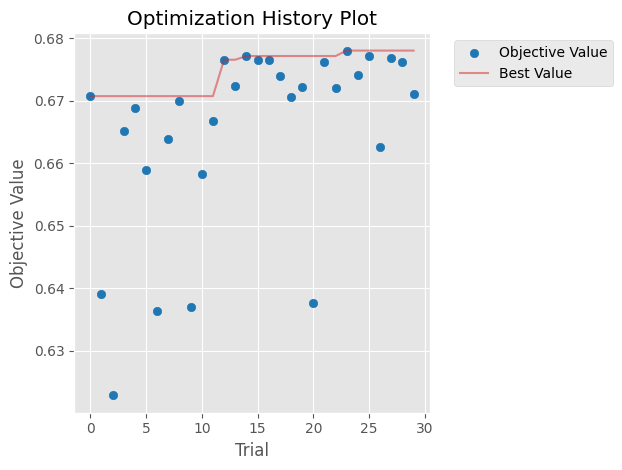

In [33]:
optuna.visualization.matplotlib.plot_optimization_history(study)

plt.show()

## Parameter Importance

/tmp/ipykernel_23/4171324235.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


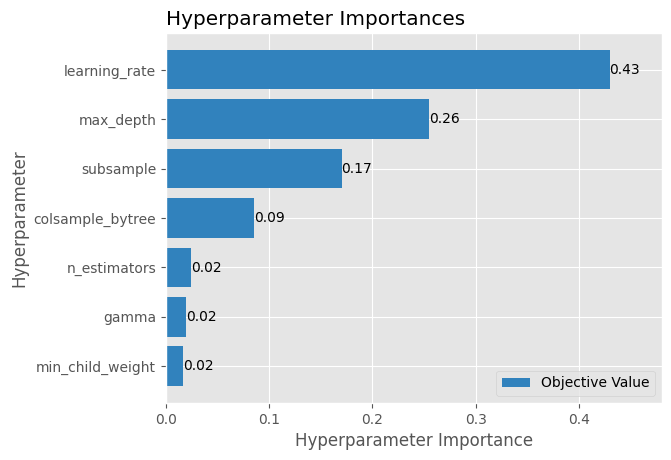

In [34]:
optuna.visualization.matplotlib.plot_param_importances(study)

plt.show()

# Conclusion

The optimized XGBoost model achieved strong predictive performance for customer churn prediction.

Key factors influencing churn included:

- Customer tenure
- Purchase frequency
- Average order value
- Support ticket activity
- Subscription level

The use of Optuna enabled efficient hyperparameter optimization, improving model performance while reducing manual experimentation.